### [ 히스토그램 정규화 ] <hr>

- 데이터 수집 후 데이터 분포 확인은 1번째 작업
- 이미지 픽셀의 분포를 확인하기 위한 용도
    * 이진화 시에 임계값 선정할 때 확인
    * 어느 한 쪽에 집중괴어 있는 픽셀을 고르게 펴주는 작업
    

In [1]:
## --------------------------
## 모듈 로딩
## --------------------------

import cv2
import os
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
import matplotlib.cm as cm
import sys
sys.path.append(r"C:\KDT14\7_CV")
import cv_utils


In [2]:
import importlib
import cv_utils

importlib.reload(cv_utils)

from cv_utils import printPlotImage

In [3]:
## -------------------------------------------
# 데이터 준비 
## -------------------------------------------

IMG_FILE= '../Images/mountain.jpg'

In [4]:
grayNP= cv2.imread(IMG_FILE, cv2.IMREAD_GRAYSCALE)
colorNP= cv2.imread(IMG_FILE)

[garyHist]  => 타입 : <class 'numpy.ndarray'>, 형태 : (256, 1),  차원 : 2D


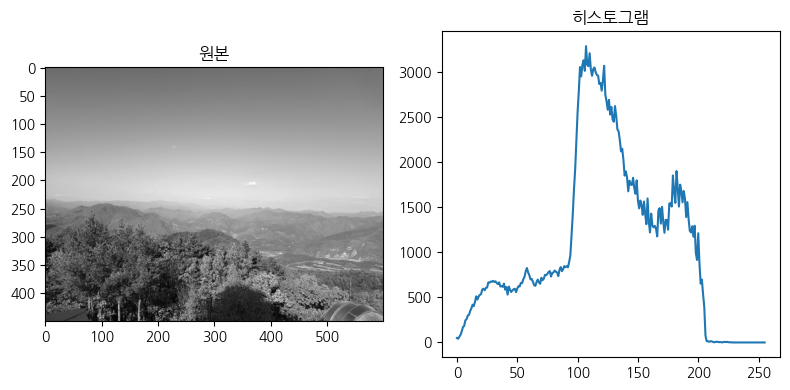

In [5]:
## 이미지 픽셀 데이터 분포 계산 : cv2.calcHist()
## =================================
## - 이미지객체, 채널 수, 마스크 => List
## - 값의 범위              => []
grayHist = cv2.calcHist([grayNP], [0], None, [256], [0, 256])

print(f'[garyHist]  => 타입 : {type(grayHist)}, 형태 : {grayHist.shape},  차원 : {grayHist.ndim}D')

## 시각화 : 원본이미지, 픽셀분포
titles_ = ['원본', '히스토그램']
plots_, images_ = [grayHist], [grayNP]
cmap_ = ['gray']

printPlotImage(1, 2, titles_, plots_, images_, cmap_)

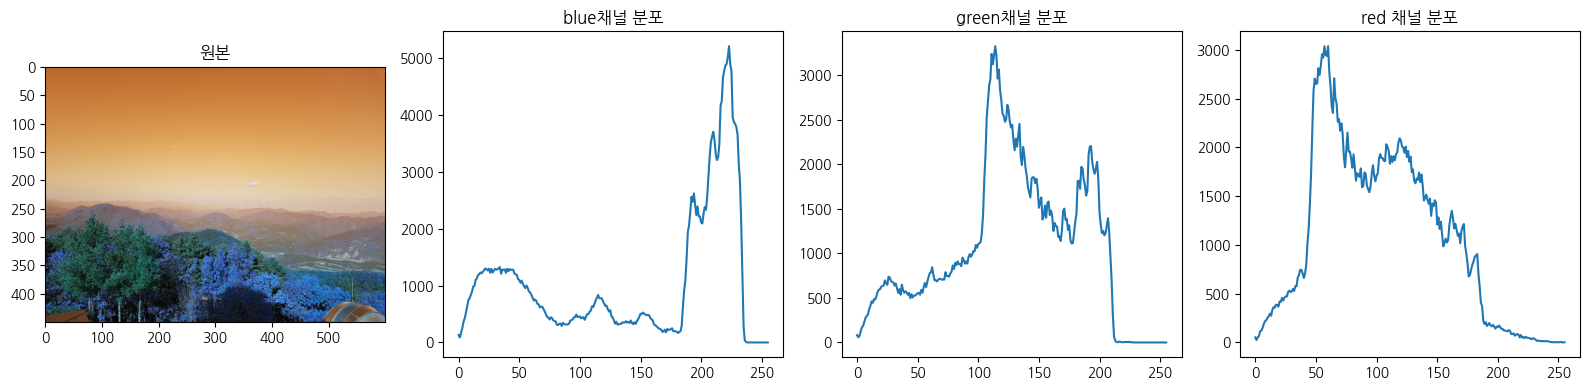

In [6]:
blueNP, greenNP, redNP = cv2.split(colorNP)

blueHist = cv2.calcHist([blueNP], [0], None, [256], [0, 256])
greenHist = cv2.calcHist([greenNP], [0], None, [256], [0, 256])
redHist = cv2.calcHist([redNP], [0], None, [256], [0, 256])

titles_ = ['원본', 'blue채널 분포', 'green채널 분포', 'red 채널 분포']
plots_, images_ = [blueHist, greenHist, redHist], [colorNP]
cmap_ = [None]

printPlotImage(1, 4, titles_, plots_, images_, cmap_)

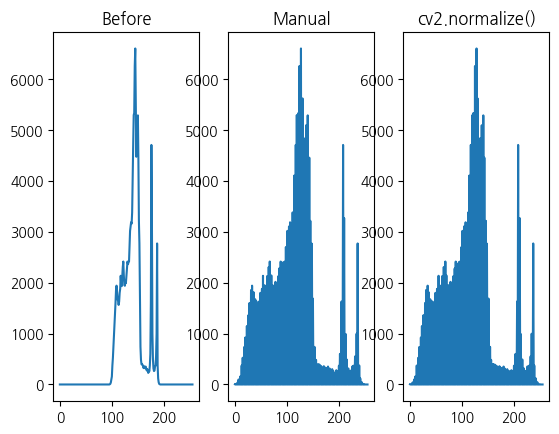

In [10]:
#--① 그레이 스케일로 영상 읽기
img = cv2.imread('../Images/abnormal.jpg', cv2.IMREAD_GRAYSCALE)

#--② 직접 연산한 정규화
img_f = img.astype(np.float32)
img_norm = ((img_f - img_f.min()) * (255) / (img_f.max() - img_f.min()))
img_norm = img_norm.astype(np.uint8)

#--③ OpenCV API를 이용한 정규화
img_norm2 = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)

#--④ 히스토그램 계산
hist = cv2.calcHist([img], [0], None, [256], [0, 255])
hist_norm = cv2.calcHist([img_norm], [0], None, [256], [0, 255])
hist_norm2 = cv2.calcHist([img_norm2], [0], None, [256], [0, 255])

cv2.imshow('Before', img)
cv2.imshow('Manual', img_norm)
cv2.imshow('cv2.normalize()', img_norm2)

hists = {'Before' : hist, 'Manual':hist_norm, 'cv2.normalize()':hist_norm2}
for i, (k, v) in enumerate(hists.items()):
    plt.subplot(1,3,i+1)
    plt.title(k)
    plt.plot(v)
plt.show()

In [ ]:
## 픽셀 100 ~ 200 사이에 집중됨. 0~100/200~255픽셀 없음 ==> 정규화 진행
mmNP = cv2.normalize(mountNP, None, 0, 255, cv2.NORM_MINMAX)

mmHist = cv2.calcHist([mmNP], [0], None, [256], [0, 256])

printPlotImage(
    1, 4,
    ['원본이미지', 'MINMAX정규화', '원본 분포', '정규화 분포'],
    [mountHist, mmHist],
    [mountNP, mmNP],
    ['gray']
)

NameError: name 'mountHist' is not defined

: 